# Evaluación robusta de clasificadores
## Notebooks 07 — Validación cruzada, métricas por clase y curvas ROC

Este notebook complementa el notebook 06. Toma los mismos datos y clasificadores,
pero reemplaza el split único por evaluaciones más rigurosas, y corrige un problema
de distribución que hacía las métricas del 06 difíciles de interpretar.

---

## Por qué el split de bloques alternos del notebook 06 tiene un problema

El split original asignaba bloques pares a train e impares a test. Esto generó:

| Conjunto | Clase 0 (ojos abiertos) | Clase 1 (ojos cerrados) |
|----------|------------------------|------------------------|
| Train    | 45.8 %                 | 54.2 %                 |
| Test     | **62.9 %**             | **37.1 %**             |

Una diferencia de 17 puntos porcentuales en la distribución de clases entre train y test
significa que **las métricas no son comparables entre ambos conjuntos**.
Un clasificador que prediga siempre "ojos abiertos" obtiene 45.8 % de accuracy en train
pero 62.9 % en test — sin aprender absolutamente nada. Eso puede hacer que un modelo
malo parezca que "mejora" al pasar de train a test.

## Soluciones implementadas en este notebook

1. **Balanced Accuracy** — promedia el recall de cada clase, eliminando el efecto del
   desbalance. Es independiente de la distribución, así que train y test son comparables.

2. **TimeSeriesSplit (5-fold)** — repite la evaluación con ventanas temporales crecientes
   (siempre se entrena con pasado y se testea con futuro). Cada fold tiene su propia
   distribución natural, y el resultado es `media ± std`: permite saber si CWT > STFT
   es consistente o producto de una partición afortunada.

3. **Métricas por clase** — Sensibilidad y Especificidad separadas para detectar sesgo.

4. **Curvas ROC** — muestra el tradeoff completo, no solo el AUC escalar.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             roc_curve)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.base import clone
warnings.filterwarnings('ignore')

# Cargar features
features_stft = pd.read_csv('data/features/features_stft.csv')
features_cwt  = pd.read_csv('data/features/features_cwt.csv')

y_stft = features_stft['label'].values
y_cwt  = features_cwt['label'].values
X_stft = features_stft.drop('label', axis=1).values
X_cwt  = features_cwt.drop('label', axis=1).values

feature_names    = features_stft.columns[:-1].tolist()
features_por_canal = ['alpha_abs', 'alpha_rel', 'entropy', 'cog']
canales_todos    = ['AF3','F7','F3','FC5','T7','P7','O1','O2','P8','T8','FC6','F4','F8','AF4']
canales_alfa     = ['O1','O2','P7','P8']

def get_feature_indices(feat_names, canales):
    idxs = []
    for canal in canales:
        for feat in features_por_canal:
            col = f"{canal}_{feat}"
            if col in feat_names:
                idxs.append(feat_names.index(col))
    return idxs

idx_config_a = get_feature_indices(feature_names, canales_todos)
idx_config_b = get_feature_indices(feature_names, canales_alfa)

print(f"STFT shape: {X_stft.shape}, CWT shape: {X_cwt.shape}")
print(f"Config A: {len(idx_config_a)} features | Config B: {len(idx_config_b)} features")
print(f"Labels: {np.bincount(y_stft)}")

STFT shape: (236, 56), CWT shape: (236, 56)
Config A: 56 features | Config B: 16 features
Labels: [128 108]


In [3]:
## Split único temporal (igual que en notebook 06)

# Se conserva el mismo split para que la tabla resumen (al final) pueda comparar
# los resultados del split único con los de la cross-validación en las mismas condiciones.
n_samples  = X_stft.shape[0]
block_size = 30
block_numbers = np.arange(n_samples) // block_size
train_idx = np.where(block_numbers % 2 == 0)[0]
test_idx  = np.where(block_numbers % 2 == 1)[0]

X_stft_train_a = X_stft[train_idx][:, idx_config_a]
X_stft_test_a  = X_stft[test_idx ][:, idx_config_a]
X_stft_train_b = X_stft[train_idx][:, idx_config_b]
X_stft_test_b  = X_stft[test_idx ][:, idx_config_b]

X_cwt_train_a  = X_cwt[train_idx][:, idx_config_a]
X_cwt_test_a   = X_cwt[test_idx ][:, idx_config_a]
X_cwt_train_b  = X_cwt[train_idx][:, idx_config_b]
X_cwt_test_b   = X_cwt[test_idx ][:, idx_config_b]

y_stft_train, y_stft_test = y_stft[train_idx], y_stft[test_idx]
y_cwt_train,  y_cwt_test  = y_cwt[train_idx],  y_cwt[test_idx]

def scale(X_tr, X_te):
    sc = StandardScaler()
    return sc.fit_transform(X_tr), sc.transform(X_te)

X_stft_train_a_sc, X_stft_test_a_sc = scale(X_stft_train_a, X_stft_test_a)
X_stft_train_b_sc, X_stft_test_b_sc = scale(X_stft_train_b, X_stft_test_b)
X_cwt_train_a_sc,  X_cwt_test_a_sc  = scale(X_cwt_train_a,  X_cwt_test_a)
X_cwt_train_b_sc,  X_cwt_test_b_sc  = scale(X_cwt_train_b,  X_cwt_test_b)

print(f"Train: {len(train_idx)} muestras  |  Test: {len(test_idx)} muestras")
print(f"Distribución train: {np.bincount(y_stft_train)} ({np.mean(y_stft_train==0):.1%} clase 0)")
print(f"Distribución test:  {np.bincount(y_stft_test)}  ({np.mean(y_stft_test==0):.1%} clase 0)")
print("\n⚠ La diferencia de distribución hace que accuracy en train y test no sean comparables.")
print("   Se agrega Balanced Accuracy para corregir esto — ver Sección 1.")

Train: 120 muestras  |  Test: 116 muestras
Distribución train: [55 65] (45.8% clase 0)
Distribución test:  [73 43]  (62.9% clase 0)

⚠ La diferencia de distribución hace que accuracy en train y test no sean comparables.
   Se agrega Balanced Accuracy para corregir esto — ver Sección 1.


In [4]:
## Definir clasificadores (idéntico a notebook 06)

classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'SVM (RBF)':           SVC(kernel='rbf', C=1.0, probability=True, class_weight='balanced', random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
}

def train_and_evaluate(X_train, X_test, y_train, y_test, model):
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    return {
        'model':   model,
        'y_pred':  y_pred,
        'y_proba': y_proba,
        'acc':     accuracy_score(y_test, y_pred),
        'bacc':    balanced_accuracy_score(y_test, y_pred),
        'f1':      f1_score(y_test, y_pred, average='macro'),
        'auc':     roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan,
        'cm':      confusion_matrix(y_test, y_pred),
    }

split_configs = [
    ('STFT', X_stft_train_a_sc, X_stft_test_a_sc, y_stft_train, y_stft_test, 'A (56 features)'),
    ('STFT', X_stft_train_b_sc, X_stft_test_b_sc, y_stft_train, y_stft_test, 'B (16 features)'),
    ('CWT',  X_cwt_train_a_sc,  X_cwt_test_a_sc,  y_cwt_train,  y_cwt_test,  'A (56 features)'),
    ('CWT',  X_cwt_train_b_sc,  X_cwt_test_b_sc,  y_cwt_train,  y_cwt_test,  'B (16 features)'),
]

results = []
print("Entrenando 12 combinaciones...\n")
for technique, X_tr, X_te, y_tr, y_te, cfg in split_configs:
    for clf_name, clf in classifiers.items():
        r = train_and_evaluate(X_tr, X_te, y_tr, y_te, clone(clf))
        results.append({'Técnica': technique, 'Config': cfg, 'Clasificador': clf_name, **r})
        print(f"  {technique} {cfg} | {clf_name:20s} — Acc: {r['acc']:.3f}  BAcc: {r['bacc']:.3f}  F1: {r['f1']:.3f}  AUC: {r['auc']:.3f}")

print("\n✓ Entrenamiento completado")

Entrenando 12 combinaciones...

  STFT A (56 features) | Logistic Regression  — Acc: 0.474  BAcc: 0.530  F1: 0.471  AUC: 0.555
  STFT A (56 features) | SVM (RBF)            — Acc: 0.491  BAcc: 0.548  F1: 0.488  AUC: 0.505
  STFT A (56 features) | Random Forest        — Acc: 0.560  BAcc: 0.608  F1: 0.560  AUC: 0.531
  STFT B (16 features) | Logistic Regression  — Acc: 0.466  BAcc: 0.494  F1: 0.465  AUC: 0.482
  STFT B (16 features) | SVM (RBF)            — Acc: 0.483  BAcc: 0.493  F1: 0.479  AUC: 0.516
  STFT B (16 features) | Random Forest        — Acc: 0.552  BAcc: 0.567  F1: 0.548  AUC: 0.525
  CWT A (56 features) | Logistic Regression  — Acc: 0.534  BAcc: 0.587  F1: 0.533  AUC: 0.594
  CWT A (56 features) | SVM (RBF)            — Acc: 0.526  BAcc: 0.552  F1: 0.525  AUC: 0.586
  CWT A (56 features) | Random Forest        — Acc: 0.500  BAcc: 0.512  F1: 0.496  AUC: 0.548
  CWT B (16 features) | Logistic Regression  — Acc: 0.526  BAcc: 0.561  F1: 0.526  AUC: 0.480
  CWT B (16 features) 

## Sección 1: Balanced Accuracy — corrigiendo el sesgo de distribución

La **Accuracy estándar** es sensible a la distribución de clases. Con 62.9 % de clase 0 en el test:
- Un clasificador que prediga siempre "ojos abiertos" (clase 0) obtiene **62.9 % de accuracy** sin aprender.
- El mismo clasificador obtiene solo **45.8 %** en el conjunto de entrenamiento.
- Eso da la apariencia de que el modelo "mejora de train a test", cuando en realidad es peor.

La **Balanced Accuracy** promedia el recall de cada clase:

$$\text{BAcc} = \frac{\text{Sensibilidad} + \text{Especificidad}}{2} = \frac{\text{TPR} + \text{TNR}}{2}$$

Al promediar los recall, normaliza la contribución de cada clase por su tamaño real.
Un clasificador que prediga siempre clase 0 obtiene **BAcc = 0.5** (aleatorio) en cualquier distribución,
mientras que la accuracy estándar varía según el desbalance del conjunto evaluado.

In [5]:
## Balanced Accuracy: comparación con Accuracy estándar

# Construir tabla con ambas métricas para ver el efecto del sesgo de distribución
rows = []
for r in results:
    tn, fp = r['cm'][0,0], r['cm'][0,1]
    fn, tp = r['cm'][1,0], r['cm'][1,1]
    rows.append({
        'Técnica':      r['Técnica'],
        'Config':       r['Config'],
        'Clasificador': r['Clasificador'],
        'Acc':          round(r['acc'],  4),
        'BAcc':         round(r['bacc'], 4),
        'Δ (BAcc-Acc)': round(r['bacc'] - r['acc'], 4),
        'Sens (C1)':    round(tp/(tp+fn) if (tp+fn)>0 else 0, 4),
        'Spec (C0)':    round(tn/(tn+fp) if (tn+fp)>0 else 0, 4),
    })

bacc_df = pd.DataFrame(rows)
print(bacc_df.to_string(index=False))

print("\n--- Interpretación de Δ (BAcc - Acc) ---")
print("  Δ > 0: la Acc estaba inflada por el desbalance del test (modelo sesgado a clase 1)")
print("  Δ < 0: la Acc estaba penalizada (modelo sesgado a clase 0, la mayoritaria en test)")
print("  Δ ≈ 0: la distribución no afectó las métricas en este caso")

print("\n--- Modelos con Sensibilidad < 0.4 (posible sesgo hacia clase 0) ---")
sesgados = bacc_df[bacc_df['Sens (C1)'] < 0.4]
if len(sesgados) > 0:
    print(sesgados[['Técnica','Config','Clasificador','Acc','BAcc','Sens (C1)','Spec (C0)']].to_string(index=False))
else:
    print("Ninguno — todos los modelos tienen recall mínimo en ambas clases")

Técnica          Config        Clasificador    Acc   BAcc  Δ (BAcc-Acc)  Sens (C1)  Spec (C0)
   STFT A (56 features) Logistic Regression 0.4741 0.5296        0.0555     0.7442     0.3151
   STFT A (56 features)           SVM (RBF) 0.4914 0.5481        0.0567     0.7674     0.3288
   STFT A (56 features)       Random Forest 0.5603 0.6077        0.0473     0.7907     0.4247
   STFT B (16 features) Logistic Regression 0.4655 0.4941        0.0286     0.6047     0.3836
   STFT B (16 features)           SVM (RBF) 0.4828 0.4935        0.0107     0.5349     0.4521
   STFT B (16 features)       Random Forest 0.5517 0.5674        0.0157     0.6279     0.5068
    CWT A (56 features) Logistic Regression 0.5345 0.5871        0.0526     0.7907     0.3836
    CWT A (56 features)           SVM (RBF) 0.5259 0.5516        0.0257     0.6512     0.4521
    CWT A (56 features)       Random Forest 0.5000 0.5119        0.0119     0.5581     0.4658
    CWT B (16 features) Logistic Regression 0.5259 0.5612   

## Sección 2: Cross-validación temporal (TimeSeriesSplit, 5 folds)

El split único entrega **una sola estimación** con alta varianza: si ese test particular fuera
más fácil o difícil que el promedio, las conclusiones serían incorrectas. Con solo 236 muestras,
esto es especialmente probable.

`TimeSeriesSplit` con K=5 divide el dataset en ventanas temporales crecientes:

| Fold | Train       | Test        |
|------|-------------|-------------|
| 1    | muestras 1–40   | 41–79  |
| 2    | muestras 1–79   | 80–118 |
| 3    | muestras 1–118  | 119–157|
| 4    | muestras 1–157  | 158–196|
| 5    | muestras 1–196  | 197–236|

Siempre se entrena con pasado y se testea con futuro — se respeta la estructura temporal
sin mezclar información de distintos momentos. El escalado va **dentro de cada fold**
para evitar que las estadísticas del test contaminen el ajuste del scaler.

In [6]:
## Cross-validación temporal con Balanced Accuracy

N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

cv_configs = [
    ('STFT', X_stft[:, idx_config_a], y_stft, 'A (56 features)'),
    ('STFT', X_stft[:, idx_config_b], y_stft, 'B (16 features)'),
    ('CWT',  X_cwt[:, idx_config_a],  y_cwt,  'A (56 features)'),
    ('CWT',  X_cwt[:, idx_config_b],  y_cwt,  'B (16 features)'),
]

cv_results = []
print(f"Cross-validación temporal (TimeSeriesSplit, {N_SPLITS} folds)\n")

for technique, X_full, y_full, config_name in cv_configs:
    for clf_name, clf_template in classifiers.items():
        fold_acc, fold_bacc, fold_f1, fold_auc = [], [], [], []

        for train_idx_cv, test_idx_cv in tscv.split(X_full):
            X_tr, X_te = X_full[train_idx_cv], X_full[test_idx_cv]
            y_tr, y_te = y_full[train_idx_cv], y_full[test_idx_cv]

            sc = StandardScaler()
            X_tr_sc = sc.fit_transform(X_tr)
            X_te_sc  = sc.transform(X_te)

            clf_fold = clone(clf_template)
            clf_fold.fit(X_tr_sc, y_tr)
            y_pred  = clf_fold.predict(X_te_sc)
            y_proba = clf_fold.predict_proba(X_te_sc)[:, 1] if hasattr(clf_fold, 'predict_proba') else None

            fold_acc.append(accuracy_score(y_te, y_pred))
            fold_bacc.append(balanced_accuracy_score(y_te, y_pred))
            fold_f1.append(f1_score(y_te, y_pred, average='macro'))
            if y_proba is not None and len(np.unique(y_te)) > 1:
                fold_auc.append(roc_auc_score(y_te, y_proba))

        cv_results.append({
            'Técnica':      technique,
            'Config':       config_name,
            'Clasificador': clf_name,
            'Acc_mean':   np.mean(fold_acc),   'Acc_std':   np.std(fold_acc),
            'BAcc_mean':  np.mean(fold_bacc),  'BAcc_std':  np.std(fold_bacc),
            'F1_mean':    np.mean(fold_f1),    'F1_std':    np.std(fold_f1),
            'AUC_mean':   np.mean(fold_auc) if fold_auc else np.nan,
            'AUC_std':    np.std(fold_auc)  if fold_auc else np.nan,
        })

        auc_str = f"AUC {np.mean(fold_auc):.3f}±{np.std(fold_auc):.3f}" if fold_auc else "AUC N/A"
        print(f"{technique} {config_name} | {clf_name:20s}: "
              f"Acc {np.mean(fold_acc):.3f}±{np.std(fold_acc):.3f}  "
              f"BAcc {np.mean(fold_bacc):.3f}±{np.std(fold_bacc):.3f}  "
              f"F1 {np.mean(fold_f1):.3f}±{np.std(fold_f1):.3f}  {auc_str}")

cv_df = pd.DataFrame(cv_results)
print("\n✓ Cross-validación completada")

Cross-validación temporal (TimeSeriesSplit, 5 folds)

STFT A (56 features) | Logistic Regression : Acc 0.472±0.146  BAcc 0.460±0.144  F1 0.451±0.146  AUC 0.462±0.215
STFT A (56 features) | SVM (RBF)           : Acc 0.508±0.041  BAcc 0.547±0.031  F1 0.493±0.056  AUC 0.558±0.098
STFT A (56 features) | Random Forest       : Acc 0.497±0.102  BAcc 0.514±0.112  F1 0.483±0.118  AUC 0.512±0.135
STFT B (16 features) | Logistic Regression : Acc 0.503±0.150  BAcc 0.539±0.134  F1 0.493±0.147  AUC 0.508±0.142
STFT B (16 features) | SVM (RBF)           : Acc 0.508±0.082  BAcc 0.491±0.115  F1 0.479±0.104  AUC 0.505±0.194
STFT B (16 features) | Random Forest       : Acc 0.492±0.052  BAcc 0.469±0.121  F1 0.467±0.094  AUC 0.440±0.150
CWT A (56 features) | Logistic Regression : Acc 0.549±0.180  BAcc 0.590±0.158  F1 0.538±0.178  AUC 0.638±0.199
CWT A (56 features) | SVM (RBF)           : Acc 0.538±0.101  BAcc 0.589±0.078  F1 0.527±0.106  AUC 0.635±0.153
CWT A (56 features) | Random Forest       : Acc 0.50

## Sección 3: Curvas ROC comparativas

Un único valor AUC no muestra **si las curvas de STFT y CWT se cruzan**.
Si se cruzan, ninguna técnica domina en todos los umbrales:
una puede ser mejor priorizando sensibilidad (minimizar falsos negativos)
y la otra priorizando especificidad (minimizar falsos positivos).
Las curvas solapadas dan una imagen completa del tradeoff.

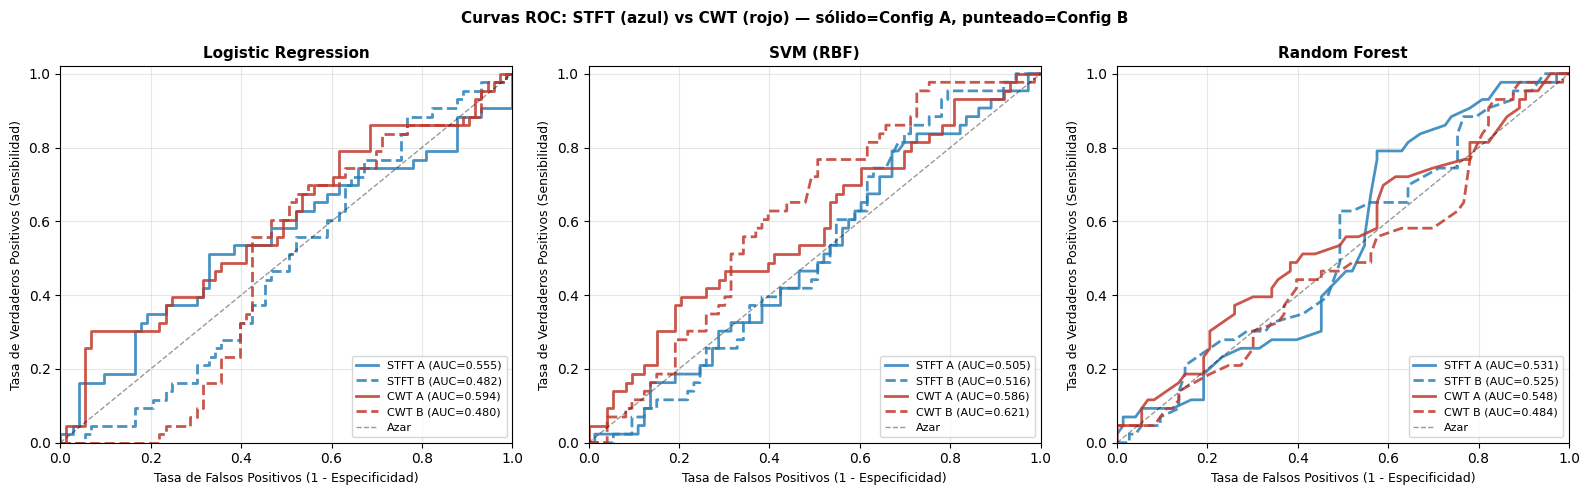

✓ Curvas ROC generadas


In [7]:
## Curvas ROC: STFT (azul) vs CWT (rojo)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Curvas ROC: STFT (azul) vs CWT (rojo) — sólido=Config A, punteado=Config B',
             fontsize=11, fontweight='bold')

colors_roc     = {'STFT': '#2980b9', 'CWT': '#c0392b'}
linestyles_roc = {'A (56 features)': '-', 'B (16 features)': '--'}

for clf_idx, clf_name in enumerate(list(classifiers.keys())):
    ax = axes[clf_idx]

    for technique in ['STFT', 'CWT']:
        for config in ['A (56 features)', 'B (16 features)']:
            r = next((x for x in results if x['Técnica'] == technique
                      and x['Config'] == config and x['Clasificador'] == clf_name), None)
            if r is None or r['y_proba'] is None:
                continue
            y_test_local = y_stft_test if technique == 'STFT' else y_cwt_test
            fpr, tpr, _ = roc_curve(y_test_local, r['y_proba'])
            label = f"{technique} {config.split('(')[0].strip()} (AUC={r['auc']:.3f})"
            ax.plot(fpr, tpr, color=colors_roc[technique],
                    linestyle=linestyles_roc[config], linewidth=2, label=label, alpha=0.85)

    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.4, label='Azar')
    ax.set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=9)
    ax.set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=9)
    ax.set_title(clf_name, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.show()
print("✓ Curvas ROC generadas")

## Sección 4: Tabla resumen — split único vs cross-validación

Esta tabla cruza ambas evaluaciones para responder:

- **¿El split único fue representativo?** Si `Acc(split) ≈ Acc_mean(CV)`, sí.
  Si `Acc(split)` es significativamente mayor que `Acc_mean(CV)`, el split único
  era optimista (ese fold particular era más fácil que el promedio).

- **¿Los resultados son estables?** Un `std` alto en CV indica que la performance
  depende mucho de qué parte del registro se usa como test — importante
  declararlo en el informe.

- **La columna BAcc(CV)** es la métrica más confiable del notebook porque combina
  corrección de distribución (balanced) con evaluación múltiple (CV).

In [8]:
## Tabla resumen final

rows_numeric = [{'Técnica': r['Técnica'], 'Config': r['Config'],
                 'Clasificador': r['Clasificador'],
                 'Acc': r['acc'], 'BAcc': r['bacc'],
                 'F1': r['f1'], 'AUC': r['auc']} for r in results]
results_numeric_df = pd.DataFrame(rows_numeric)

summary_rows = []
for _, row_cv in cv_df.iterrows():
    row_split = results_numeric_df[
        (results_numeric_df['Técnica']      == row_cv['Técnica']) &
        (results_numeric_df['Config']       == row_cv['Config']) &
        (results_numeric_df['Clasificador'] == row_cv['Clasificador'])
    ].iloc[0]

    summary_rows.append({
        'Técnica':      row_cv['Técnica'],
        'Config':       row_cv['Config'],
        'Clasificador': row_cv['Clasificador'],
        'Acc (split)':  f"{row_split['Acc']:.3f}",
        'BAcc (split)': f"{row_split['BAcc']:.3f}",
        'Acc (CV)':     f"{row_cv['Acc_mean']:.3f}±{row_cv['Acc_std']:.3f}",
        'BAcc (CV)':    f"{row_cv['BAcc_mean']:.3f}±{row_cv['BAcc_std']:.3f}",
        'F1 (CV)':      f"{row_cv['F1_mean']:.3f}±{row_cv['F1_std']:.3f}",
        'AUC (CV)':     f"{row_cv['AUC_mean']:.3f}±{row_cv['AUC_std']:.3f}",
    })

summary_df = pd.DataFrame(summary_rows)
print('=' * 110)
print('TABLA RESUMEN: Split único vs Cross-validación (5-fold TimeSeriesSplit)')
print('=' * 110)
print(summary_df.to_string(index=False))

print("\n--- Mejor combinación según BAcc (CV) — métrica más confiable ---")
best_cv = cv_df.loc[cv_df['BAcc_mean'].idxmax()]
print(f"{best_cv['Técnica']} + {best_cv['Config']} + {best_cv['Clasificador']}: "
      f"BAcc {best_cv['BAcc_mean']:.3f}±{best_cv['BAcc_std']:.3f}, "
      f"F1 {best_cv['F1_mean']:.3f}±{best_cv['F1_std']:.3f}, "
      f"AUC {best_cv['AUC_mean']:.3f}±{best_cv['AUC_std']:.3f}")

TABLA RESUMEN: Split único vs Cross-validación (5-fold TimeSeriesSplit)
Técnica          Config        Clasificador Acc (split) BAcc (split)    Acc (CV)   BAcc (CV)     F1 (CV)    AUC (CV)
   STFT A (56 features) Logistic Regression       0.474        0.530 0.472±0.146 0.460±0.144 0.451±0.146 0.462±0.215
   STFT A (56 features)           SVM (RBF)       0.491        0.548 0.508±0.041 0.547±0.031 0.493±0.056 0.558±0.098
   STFT A (56 features)       Random Forest       0.560        0.608 0.497±0.102 0.514±0.112 0.483±0.118 0.512±0.135
   STFT B (16 features) Logistic Regression       0.466        0.494 0.503±0.150 0.539±0.134 0.493±0.147 0.508±0.142
   STFT B (16 features)           SVM (RBF)       0.483        0.493 0.508±0.082 0.491±0.115 0.479±0.104 0.505±0.194
   STFT B (16 features)       Random Forest       0.552        0.567 0.492±0.052 0.469±0.121 0.467±0.094 0.440±0.150
    CWT A (56 features) Logistic Regression       0.534        0.587 0.549±0.180 0.590±0.158 0.538±0.178 0.63